In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

In [3]:
import os, json
from datetime import datetime
import torch

epoch = int(20)
patience = int(3)
bs = int(16)

CFG = {
  "img_size": (128,768),
  "pad_idx": 112,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/train/crohme/hme",
      "pme_img": "data/train/crohme/pme",
      "caption": "data/train/crohme/caption.txt"
    },
    "im2latex": {
      "hme_img": "data/train/im2latex/hme",
      "pme_img": "data/train/im2latex/pme",
      "caption": "data/train/im2latex/caption.txt"
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": "adadelta",
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = "DLA"
scheduler_name = "CosineAnnealingWarmup"
steps = int(442)
min_lr = float(0.005)
max_lr = float(0.1)

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

# params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
#                                         "cycle_mult": 1.0,
#                                         "max_lr": max_lr,
#                                         "min_lr": min_lr,
#                                         "warmup_steps": steps*epoch*0.1,  # 약 2에포크
#                                         "gamma": 1.0
#                                         }
# scheduler_info["params"] = params_cosineAnnealingWarmupRestarts

from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

params_sequentialLR = {
    "lr": max_lr,
    "start_factor": min_lr / max_lr,
    "end_factor": 1.0,
    "total_iters": int(steps*0.2),
    "T_max": int(steps*0.8),
    "eta_min": min_lr,
    "milestones": [int(steps*0.2)]
}

scheduler_info["params"] = params_sequentialLR

CFG["scheduler"] = scheduler_info

# MODEL

## Encoder

In [4]:
import torch
import torch.nn as nn
from torchvision.models import densenet121, DenseNet121_Weights


class DenseNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()
        densenet = densenet121(weights=None)    # 이번 프로젝트는 imageNet 데이터에 비교하면 수식글씨로, imageNet 가중치가 방해될 수도 있어 사전학습 가중치 없이 불러오는게 유리할수도 있음

        # First conv layer 수정: in_channels=1로 (우리 프로젝트에 맞춰 gpu 메모리 소모 줄이기 위해 그레이스케일로 변환)
        densenet.features.conv0 = nn.Conv2d(
            in_channels=1, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        # Remove classification head
        features = list(densenet.features.children())

        # Use all layers except final norm+relu+avgpool
        self.backbone = nn.Sequential(*features[:-1])

        # 가중치 초기화
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.backbone(x)                       # (B,1,128,768) -> (B,1024,4,24)
        B, D, _, _ = x.shape
        x = x.reshape(B, D, -1)                    # (B,1024,4*24)
        x = x.transpose(1,2)                       # (B,1024,96) -> (B,96,1024)
        return x


## Decoder

In [5]:
import torch
import torch.nn as nn

class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_dim_enc=1024, hidden_dim=256, emb_dim_dec=1024, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(emb_dim_enc+emb_dim_dec, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)


        # weight initialization

        # nn.GRU
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, prev_token, hidden, context):

        # prev_token: (B,D_dec)
        # hidden: (B,H)
        # context: (B,D_enc)

        # 지금은 num_layers는 무조건 1이라서 context는 (B,L,H) 대신 (B,1,H), hidden은 (D*L,B,H) 대신 (D,B,H)로 받는다고 생각하고 unsqueeze 등 shape 변경

        prev_token = prev_token.unsqueeze(1)                  # (B,D_dec) -> (B,1,D_dec)
        context = context.unsqueeze(1)                        # (B,D_enc) -> (B,1,D_enc)

        dec_input = torch.cat([prev_token, context], dim=-1)  # (B,1,D_dec+D_enc)

        # nn.GRU에서 요구하는 hidden 형상 (D*L,B,H)가 되도록 변경
        hidden = hidden.unsqueeze(0)

        output, hidden = self.gru(dec_input, hidden)
        output = output.squeeze(1)                       # (B,1,H) -> (B,H)
        hidden = hidden.squeeze(0)                       # (1,B,H) -> (B,H)

        output_logits = self.fc_out(output)             # (B,H) -> (B,V)
        return output_logits, hidden


## Attention

In [6]:
# paired한 학습이 아니라 단일 도메인에 대해 돌렸을때 성능 나오는지 확인하기 위해 Paired 없을때 단일도메인 내 인코더-디코더 간 어텐션만 추가해서 구성한 Lite 모델

import torch.nn.functional as F
import random


# 디코더에서 패딩되어 들어오는 gt: (B,T)에서, pad를 제외한 실제 길이에 해당하는 length: (B,)를 구해서 pad부분은 tf 적용하지 않도록 할 떄 이용하는 함수
def get_lengths(labels, eos_id):

    # eos 위치 찾기 (없으면 전부 길이로)
    eos_mask = (labels == eos_id)
    # eos가 처음 등장하는 인덱스
    lengths = eos_mask.float().argmax(dim=1)

    # 만약 eos가 없는 경우 (argmax가 0을 반환) → 전체 길이로 처리
    lengths[lengths == 0] = labels.size(1)

    return lengths


class DLAModel(nn.Module):
    def __init__(self, model_config=None):
        super().__init__()

        # 설정 파라미터 추출
        self.vocab_size = model_config.get("vocab_size", 112)
        self.enc_emb_dim = model_config.get("encoder_emb_dim", 256)
        self.dec_emb_dim = model_config.get("decoder_emb_dim", 256)
        self.dec_hid_dim = model_config.get("decoder_hidden_dim", 512)

        self.embed = nn.Embedding(self.vocab_size, self.dec_emb_dim)

        # 인코더
        self.encoder = DenseNetEncoder()
        self.encoder_proj = nn.Linear(1024, self.enc_emb_dim)

        # 바다나우 어텐션 위한 파라미터
        self.W_enc = nn.Linear(self.enc_emb_dim, self.dec_hid_dim, bias=False)
        self.W_hidden = nn.Linear(self.dec_hid_dim, self.dec_hid_dim, bias=True)
        self.W_coverage = nn.Linear((CFG["img_size"][0]//32) * (CFG["img_size"][1]//32), self.dec_hid_dim, bias=False)
        self.v = nn.Linear(self.dec_hid_dim, 1, bias=False)

        # 디코더
        self.decoder = Decoder(self.vocab_size, self.enc_emb_dim, self.dec_hid_dim, self.dec_emb_dim)


        # weight initialization

        # 임베딩 레이어
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)

        # nn.Linear
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, images_hme, images_pme, labels, tf_ratio=CFG["training"]["tf_ratio"]):

        # images: (B,1,128,768)
        # labels: (B,T)

        enc_hme = self.encoder(images_hme)     # (B,96,1024)
        enc_hme = self.encoder_proj(enc_hme)   # (B,96,1024) -> (B,96,D_enc)

        if images_pme is not None:
            enc_pme = self.encoder(images_pme)
            enc_pme = self.encoder_proj(enc_pme)

        B = enc_hme.shape[0]               # batch size

        T = labels.shape[1]            # max_seq_len => <sos>, <eos> 포함

        # HME 디코딩
        dec_out_hme = []
        dec_out_pme = []

        # <sos>
        prev_token_hme = labels[:, 0]             # (B,) - <sos>
        prev_token_hme = self.embed(prev_token_hme)   # (B,) -> (B,D_dec)
        prev_hidden_hme = torch.zeros((B, self.dec_hid_dim), device=images_hme.device)     # (B,H)
        coverage_hme = None

        if images_pme is not None:
            prev_token_pme = labels[:, 0]             # (B,) - <sos>
            prev_token_pme = self.embed(prev_token_pme)   # (B,) -> (B,D_dec)
            prev_hidden_pme = torch.zeros((B, self.dec_hid_dim), device=images_hme.device)     # (B,H)
            coverage_pme = None

        length = get_lengths(labels, eos_id=CFG["eos_idx"]) # (B,)

        for t in range(1,T):

            # tf mask
            tf_mask = torch.rand(B, device=images_hme.device) < tf_ratio  # (B,)
            valid_mask = t < length                                   # (B,)
            final_mask = tf_mask & valid_mask                         # (B,)


            # HME
            if coverage_hme is None:
                scores_hme = torch.tanh(self.W_enc(enc_hme) + self.W_hidden(prev_hidden_hme).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

            elif coverage_hme is not None:
                scores_hme = torch.tanh(self.W_enc(enc_hme) + self.W_hidden(prev_hidden_hme).unsqueeze(1) + self.W_coverage(coverage_hme).unsqueeze(1))

            scores_hme = self.v(scores_hme).squeeze(2)         # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff_hme = F.softmax(scores_hme, dim=-1)     # (B,96)

            if coverage_hme is None:
                coverage_hme = attn_coeff_hme

            elif coverage_hme is not None:
                coverage_hme = coverage_hme + attn_coeff_hme

            context_hme = enc_hme.transpose(1,2) @ attn_coeff_hme.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context_hme = context_hme.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

            logits_y_hme, cur_hidden_hme = self.decoder(prev_token_hme, prev_hidden_hme, context_hme)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out_hme.append(logits_y_hme)

            # 기본값은 모델 예측 argmax
            prev_token_hme = logits_y_hme.argmax(dim=-1)

            # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
            prev_token_hme[final_mask] = labels[final_mask, t]

            prev_token_hme = self.embed(prev_token_hme)       # (B,) -> (B,D_dec)
            prev_hidden_hme = cur_hidden_hme


            # PME
            if images_pme is not None:
                if coverage_pme is None:
                    scores_pme = torch.tanh(self.W_enc(enc_pme) + self.W_hidden(prev_hidden_pme).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

                elif coverage_pme is not None:
                    scores_pme = torch.tanh(self.W_enc(enc_pme) + self.W_hidden(prev_hidden_pme).unsqueeze(1) + self.W_coverage(coverage_pme).unsqueeze(1))

                scores_pme = self.v(scores_pme).squeeze(2)         # (B,96,H) -> (B,96,1) -> (B,96)
                attn_coeff_pme = F.softmax(scores_pme, dim=-1)     # (B,96)

                if coverage_pme is None:
                    coverage_pme = attn_coeff_pme

                elif coverage_pme is not None:
                    coverage_pme = coverage_pme + attn_coeff_pme

                context_pme = enc_pme.transpose(1,2) @ attn_coeff_pme.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
                context_pme = context_pme.squeeze(2)               # (B,D_enc,1) -> (B,D_enc)

                logits_y_pme, cur_hidden_pme = self.decoder(prev_token_pme, prev_hidden_pme, context_pme)    # logits_y: (B,V), cur_hidden: (B,H)
                dec_out_pme.append(logits_y_pme)

                # 기본값은 모델 예측 argmax
                prev_token_pme = logits_y_pme.argmax(dim=-1)

                # teacher forcing 적용할 위치는 정답 label로 덮어쓰기
                prev_token_pme[final_mask] = labels[final_mask, t]

                prev_token_pme = self.embed(prev_token_pme)       # (B,) -> (B,D_dec)
                prev_hidden_pme = cur_hidden_pme


        dec_out_hme = torch.stack(dec_out_hme)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out_hme = dec_out_hme.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        if images_pme is None:
            return dec_out_hme, None, None, None

        else:
            dec_out_pme = torch.stack(dec_out_pme)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
            dec_out_pme = dec_out_pme.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

            return dec_out_hme, dec_out_pme, enc_hme, enc_pme


    def inference(self, images, max_seq_len):

        # images: (B,1,128,768)

        enc = self.encoder(images)     # (B,96,D_enc)
        enc = self.encoder_proj(enc)   # (B,96,1024) -> (B,96,D_enc)

        B = enc.shape[0]               # batch size

        # PME 디코딩
        dec_out = []

        # <sos>
        prev_token = torch.zeros(B, dtype=torch.long, device=images.device)         # (B,) - <sos>
        prev_token = self.embed(prev_token)                                        # (B,) -> (B,D_dec)

        prev_hidden = torch.zeros((B, self.dec_hid_dim), device=images.device)     # (B,H)

        coverage = None

        for t in range(1,max_seq_len):

            if coverage is None:
                scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1))   # 브로드캐스팅 -> (B,96,H)

            elif coverage is not None:
                scores = torch.tanh(self.W_enc(enc) + self.W_hidden(prev_hidden).unsqueeze(1) + self.W_coverage(coverage).unsqueeze(1))

            scores = self.v(scores).squeeze(2)        # (B,96,H) -> (B,96,1) -> (B,96)
            attn_coeff = F.softmax(scores, dim=-1)   # (B,96)

            if coverage is None:
                coverage = attn_coeff

            elif coverage is not None:
                coverage = coverage + attn_coeff

            context = enc.transpose(1,2) @ attn_coeff.unsqueeze(2)   # (B,D_enc,96)@(B,96,1) -> (B,D_enc,1)
            context = context.squeeze(2)               # (B,D_enc,1) -> (B,D_enc) == (B,D_enc)

            logits_y, cur_hidden = self.decoder(prev_token, prev_hidden, context)    # logits_y: (B,V), cur_hidden: (B,H)
            dec_out.append(logits_y)

            # inference 시점이므로 teacher forcing 적용하지 않음
            prev_token = logits_y.argmax(dim=-1)  # (B,V) -> (B,)

            prev_token = self.embed(prev_token)       # (B,) -> (B,D_dec)
            prev_hidden = cur_hidden


        dec_out = torch.stack(dec_out)         # (T-1,B,V)   # <eos>부분은 입력에서 들어오지 않으므로 T가 아닌 T-1
        dec_out = dec_out.transpose(0,1)       # (T-1,B,V) -> (B,T-1,V)

        return dec_out

# Attention 시각화

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from torchvision import transforms
from skimage.transform import resize, pyramid_expand
from PIL import Image
from torchvision import transforms

# -----------------------
# 1. 모델 불러오기
# -----------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# checkpoint 로드
model = DLAModel(model_config=CFG["model"]).to(device)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])
model.eval()

# -----------------------
# 2. 입력 이미지 로드
# -----------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # 혹시 컬러 이미지 대비용
    transforms.Resize(CFG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
to_pil_image = transforms.ToPILImage()

# -----------------------
# 3. inference + attention 추출
# -----------------------
def inference_with_attention(model, image, max_seq_len):
    """
    기존 DLAModel.inference()를 약간 수정해
    각 step별 attention coefficient를 저장하는 버전
    """
    model.eval()
    attn_list = []

    enc = model.encoder(image)  # (B,96,1024)
    enc = model.encoder_proj(enc)  # (B,96,D_enc)

    B = enc.shape[0]
    prev_token = torch.zeros(B, dtype=torch.long, device=image.device)  # <sos>
    prev_token = model.embed(prev_token)
    prev_hidden = torch.zeros((B, model.dec_hid_dim), device=image.device)
    coverage = None

    for t in range(1, max_seq_len):
        if coverage is None:
            scores = torch.tanh(
                model.W_enc(enc) + model.W_hidden(prev_hidden).unsqueeze(1)
            )
        else:
            scores = torch.tanh(
                model.W_enc(enc)
                + model.W_hidden(prev_hidden).unsqueeze(1)
                + model.W_coverage(coverage).unsqueeze(1)
            )

        scores = model.v(scores).squeeze(2)
        attn_coeff = F.softmax(scores, dim=-1)  # (B,96)
        attn_list.append(attn_coeff[0].detach().cpu().numpy())

        # coverage 업데이트
        coverage = attn_coeff if coverage is None else coverage + attn_coeff

        context = enc.transpose(1, 2) @ attn_coeff.unsqueeze(2)
        context = context.squeeze(2)

        logits_y, cur_hidden = model.decoder(prev_token, prev_hidden, context)
        prev_token = logits_y.argmax(dim=-1)
        prev_token = model.embed(prev_token)
        prev_hidden = cur_hidden

    return logits_y, attn_list

# -----------------------
# 4. 어텐션 시각화 함수
# -----------------------
def show_attention_overlay(img_tensor, attn_list, tokens=None, H_enc=8, W_enc=12, smooth=True):
    """
    img_tensor: (1,1,H,W)
    attn_list: list of (T_enc,) attention arrays
    tokens: 예측된 토큰 시퀀스 (optional)
    """
    pil_img = to_pil_image(img_tensor[0])
    _, _, H, W = img_tensor.size()

    for i, attn in enumerate(attn_list):
        attn_2d = attn.reshape(H_enc, W_enc)
        if smooth:
            attn_resized = pyramid_expand(attn_2d, upscale=max(H//H_enc, W//W_enc), channel_axis=None)
        else:
            attn_resized = resize(attn_2d, (H, W), mode="reflect", anti_aliasing=True)

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(pil_img, cmap="gray")
        ax.imshow(attn_resized, cmap=cm.jet, alpha=0.5)
        if tokens is not None:
            ax.set_title(f"Step {i+1}: {tokens[i]}", fontsize=14)
        ax.axis("off")
        plt.show()

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

torch.Size([1, 96, 1024])


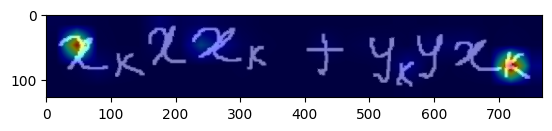

In [ ]:
# Example 1

img_path = "data/test/crohme/hme/2014/18_em_0.png"  # 테스트 이미지 경로
image = Image.open(img_path).convert("L")
image = transform(image).unsqueeze(0).to(device)  # (1,1,H,W)

# 실행
max_seq_len = 60
_, attn_list = inference_with_attention(model, image, max_seq_len=max_seq_len)

with torch.no_grad():
    feat = model.encoder(image)
    print(feat.shape)

attn_tensor = torch.tensor(attn_list[0]).view(1,1,4,24)
attn_up = F.interpolate(attn_tensor, size=(128,768), mode='bilinear', align_corners=False)
plt.imshow(to_pil_image(image[0]), cmap='gray')
plt.imshow(attn_up[0,0].numpy(), cmap='jet', alpha=0.5)
plt.show()

torch.Size([1, 96, 1024])


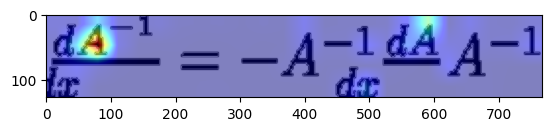

In [ ]:
# Example 2

img_path = "data/test/crohme/pme/2016/UN_101_em_4.png"  # 테스트 이미지 경로
image = Image.open(img_path).convert("L")
image = transform(image).unsqueeze(0).to(device)  # (1,1,H,W)

# 실행
max_seq_len = 60
_, attn_list = inference_with_attention(model, image, max_seq_len=max_seq_len)

with torch.no_grad():
    feat = model.encoder(image)
    print(feat.shape)

attn_tensor = torch.tensor(attn_list[0]).view(1,1,4,24)
attn_up = F.interpolate(attn_tensor, size=(128,768), mode='bilinear', align_corners=False)
plt.imshow(to_pil_image(image[0]), cmap='gray')
plt.imshow(attn_up[0,0].numpy(), cmap='jet', alpha=0.5)
plt.show()

torch.Size([1, 96, 1024])


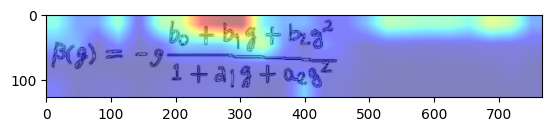

In [ ]:
# Example 3

img_path = "data/test/im2latex/hme/621.png"  # 테스트 이미지 경로
image = Image.open(img_path).convert("L")
image = transform(image).unsqueeze(0).to(device)  # (1,1,H,W)

# 실행
max_seq_len = 60
_, attn_list = inference_with_attention(model, image, max_seq_len=max_seq_len)

with torch.no_grad():
    feat = model.encoder(image)
    print(feat.shape)

attn_tensor = torch.tensor(attn_list[0]).view(1,1,4,24)
attn_up = F.interpolate(attn_tensor, size=(128,768), mode='bilinear', align_corners=False)
plt.imshow(to_pil_image(image[0]), cmap='gray')
plt.imshow(attn_up[0,0].numpy(), cmap='jet', alpha=0.5)
plt.show()

torch.Size([1, 96, 1024])


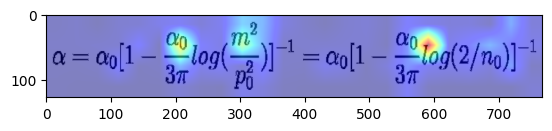

In [ ]:
# Example 4

img_path = "data/test/im2latex/pme/2681.png"  # 테스트 이미지 경로
image = Image.open(img_path).convert("L")
image = transform(image).unsqueeze(0).to(device)  # (1,1,H,W)

# 실행
max_seq_len = 60
_, attn_list = inference_with_attention(model, image, max_seq_len=max_seq_len)

with torch.no_grad():
    feat = model.encoder(image)
    print(feat.shape)

attn_tensor = torch.tensor(attn_list[0]).view(1,1,4,24)
attn_up = F.interpolate(attn_tensor, size=(128,768), mode='bilinear', align_corners=False)
plt.imshow(to_pil_image(image[0]), cmap='gray')
plt.imshow(attn_up[0,0].numpy(), cmap='jet', alpha=0.5)
plt.show()